In [1]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import time
import numpy as np
import awkward as ak
import pandas as pd
from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, EnergyTools, vector
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)

<module 'python.analysis.SelectionTools' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/analysis/SelectionTools.py'>

In [2]:
filename = "/storage/2/gj23442/pdhd_prod_mc_beam__gen_g4_IonScintPDExt_PDInt_1GeV_v10_10_04d01_nosce.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

<BarContainer object of 8 artists>

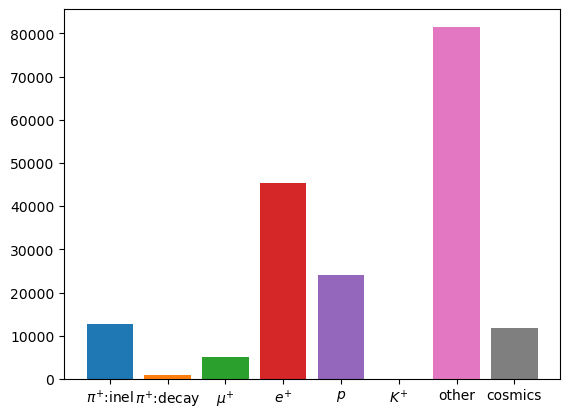

In [16]:
tags = Tags.GenerateTrueBeamParticleTags(events)
plt.bar(tags.name.values, ak.sum(tags.mask.values, axis=1), color= tags.colour.values)

In [17]:
def signal_mask(evts):
    mask = (evts.trueParticlesBT.beam_pdg == 211) & (evts.trueParticlesBT.beam_endProcess == evts.trueParticles.true_beam_endProcess)
    return mask

def true_signal_mask(evts):
    beam_pdg = ak.firsts(evts.trueParticles.pdg[events.trueParticles.number == 1])
    mask = beam_pdg == 211
    return mask

In [18]:
def tpc_entrance_mask(evts):
    traj_z = evts.trueParticles.beam_traj_pos.z
    traj_z = traj_z[traj_z >= 0]
    mask = evts.trueParticles.beam_traj_pos.z == ak.firsts(traj_z)
    return mask

def true_particle_masks(evts):
    beam_particles = evts.trueParticles.pdg[:, 0]
    pion_mask = beam_particles == 211
    muon_mask = (beam_particles == -13) | (beam_particles == 13)
    rest_mask = ~(pion_mask | muon_mask)
    return pion_mask, muon_mask, rest_mask

def particle_masks(evts):
    beam_particles = evts.trueParticlesBT.beam_pdg
    endprocess_mask = evts.trueParticlesBT.beam_endProcess == evts.trueParticles.true_beam_endProcess
    pion_mask = (beam_particles == 211) & endprocess_mask
    muon_mask = ((beam_particles == -13) | (beam_particles == 13)) & endprocess_mask
    rest_mask = ~(pion_mask | muon_mask)
    return pion_mask, muon_mask, rest_mask

# Energy

In [19]:
beam_traj_pos = tpc_entrance_mask(events)
pion_mask, muon_mask, rest_mask = true_particle_masks(events)

In [20]:
beam_traj_KE = events.trueParticles.beam_traj_KE
beam_KE = ak.firsts(beam_traj_KE[beam_traj_pos])
beam_pion_KE = ak.firsts(beam_traj_KE[beam_traj_pos & pion_mask])
beam_muon_KE = ak.firsts(beam_traj_KE[beam_traj_pos & muon_mask])
beam_rest_KE = ak.firsts(beam_traj_KE[beam_traj_pos & rest_mask])

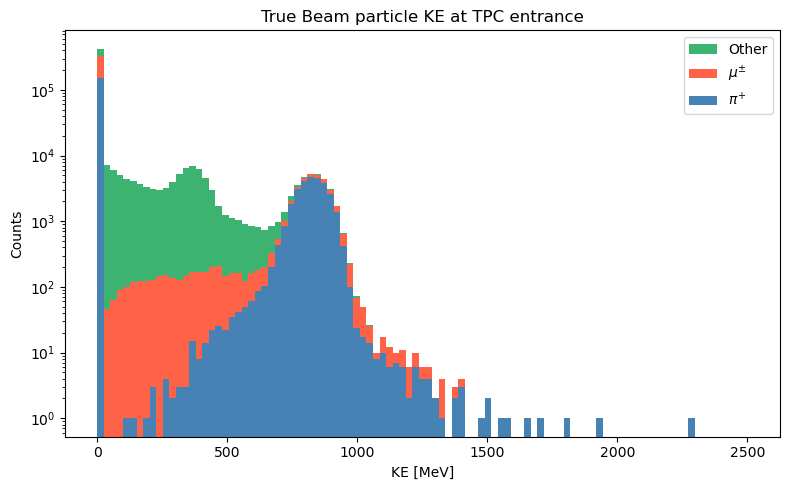

In [21]:
# Convert awkward arrays to numpy, dropping Nones from ak.firsts
pion_KE  = ak.fill_none(beam_pion_KE, 0)
muon_KE  = ak.fill_none(beam_muon_KE, 0)
rest_KE  = ak.fill_none(beam_rest_KE, 0)
beam_KE = ak.fill_none(beam_KE, 0)

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [pion_KE, muon_KE, rest_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(beam_KE, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('True Beam particle KE at TPC entrance')
ax.legend()
plt.tight_layout()
plt.show()

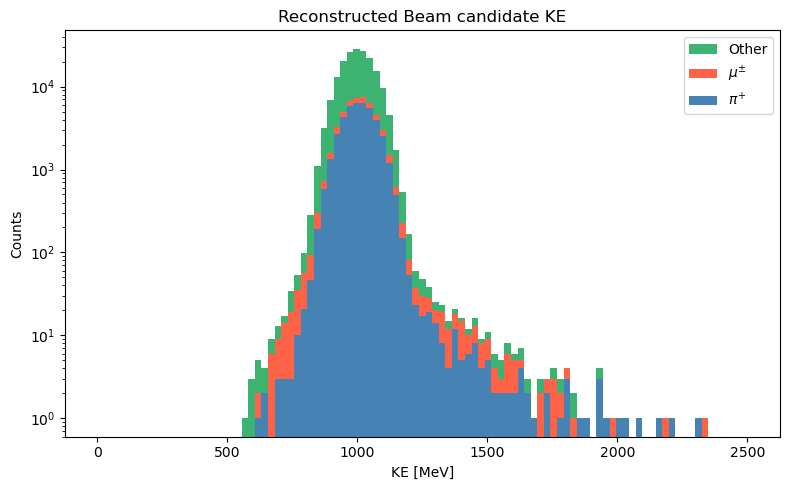

In [22]:
reco_energy = events.recoParticles.beam_inst_P

reco_pion_KE = reco_energy[pion_mask]
reco_muon_KE = reco_energy[muon_mask]
reco_rest_KE = reco_energy[rest_mask]

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [reco_pion_KE, reco_muon_KE, reco_rest_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(reco_energy, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('Reconstructed Beam candidate KE')
ax.legend()
plt.tight_layout()
plt.show()

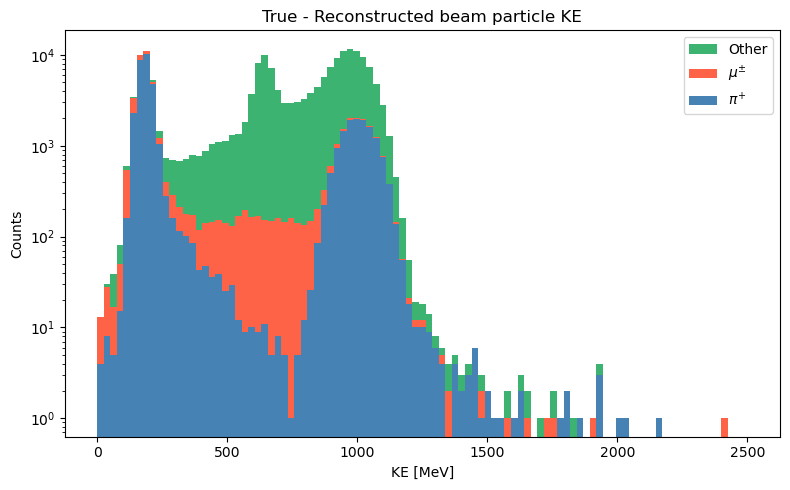

In [23]:
res_energy = reco_energy - beam_KE

res_pion_KE = res_energy[pion_mask]
res_muon_KE = res_energy[muon_mask]
res_rest_KE = res_energy[rest_mask]

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [res_pion_KE, res_muon_KE, res_rest_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(reco_energy, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('True - Reconstructed beam particle KE')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
beam_startpos = events.trueParticles.beam_traj_pos[beam_traj_pos]
beam_startpos = ak.firsts(beam_startpos)

beam_startpos = ak.zip({
    "x": ak.fill_none(beam_startpos.x, -999),
    "y": ak.fill_none(beam_startpos.y, -999),
    "z": ak.fill_none(beam_startpos.z, -999),
})

pion_startpos = beam_startpos[pion_mask]
muon_startpos = beam_startpos[muon_mask]
rest_startpos = beam_startpos[rest_mask]

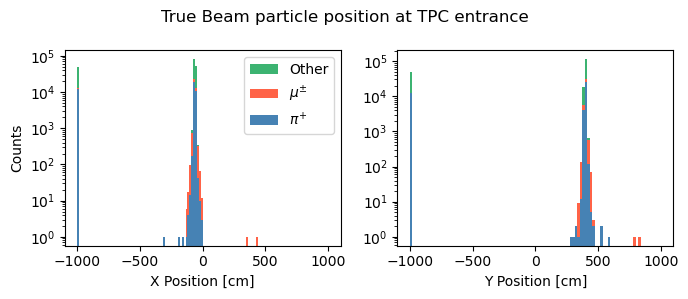

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)


ax[0].hist(
    [pion_startpos.x, muon_startpos.x, rest_startpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [pion_startpos.y, muon_startpos.y, rest_startpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)

ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('True Beam particle position at TPC entrance')
ax[0].legend()
plt.tight_layout()
plt.show()

(380.0, 420.0)

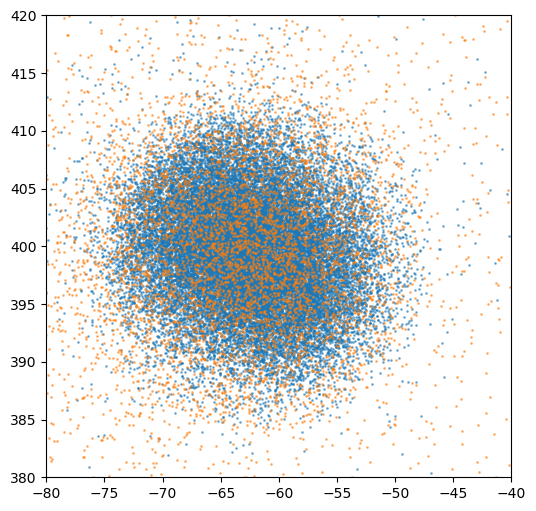

In [47]:
limit_x = [-80, -40]
limit_y = [380, 420]
plt.figure(figsize=(6, 6))
plt.scatter(pion_startpos.x[pion_startpos.x != -999], pion_startpos.y[pion_startpos.x != -999], s=1, alpha=0.5)
plt.scatter(muon_startpos.x[muon_startpos.x != -999], muon_startpos.y[muon_startpos.x != -999], s=1, alpha=0.5)
plt.xlim(limit_x)
plt.ylim(limit_y)

In [26]:
reco_startpos = events.recoParticles.beam_startPos_SCE

reco_pion_startpos = reco_startpos[pion_mask]
reco_muon_startpos = reco_startpos[muon_mask]
reco_rest_startpos = reco_startpos[rest_mask]

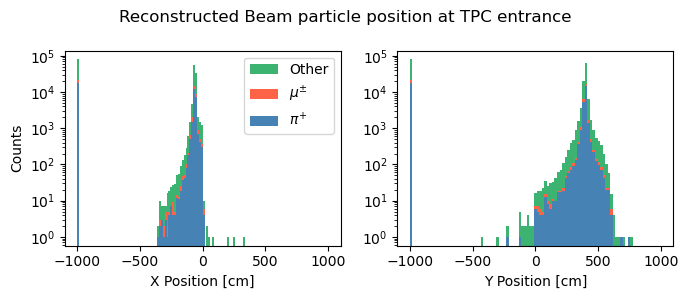

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)


ax[0].hist(
    [reco_pion_startpos.x, reco_muon_startpos.x, reco_rest_startpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [reco_pion_startpos.y, reco_muon_startpos.y, reco_rest_startpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)

ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('Reconstructed Beam particle position at TPC entrance')
ax[0].legend()
plt.tight_layout()
plt.show()

In [28]:
res_startpos_x = reco_startpos.x - beam_startpos.x

res_pion_x = res_startpos_x[pion_mask]
res_muon_x = res_startpos_x[muon_mask]
res_rest_x = res_startpos_x[rest_mask]

res_startpos_y = reco_startpos.y - beam_startpos.y

res_pion_y = res_startpos_y[pion_mask]
res_muon_y = res_startpos_y[muon_mask]
res_rest_y = res_startpos_y[rest_mask]

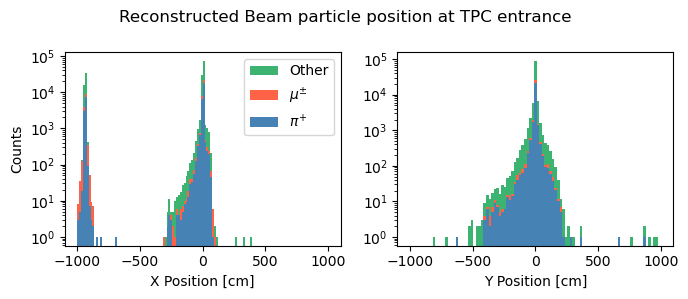

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)


ax[0].hist(
    [res_pion_x, res_muon_x, res_rest_x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [res_pion_y, res_muon_y, res_rest_y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)

ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('Reconstructed Beam particle position at TPC entrance')
ax[0].legend()
plt.tight_layout()
plt.show()

In [30]:
true_beam_endpos = events.trueParticles.endPos

pion_endpos = true_beam_endpos[:, 0][pion_mask]
muon_endpos = true_beam_endpos[:, 0][muon_mask]
rest_endpos = true_beam_endpos[:, 0][rest_mask]

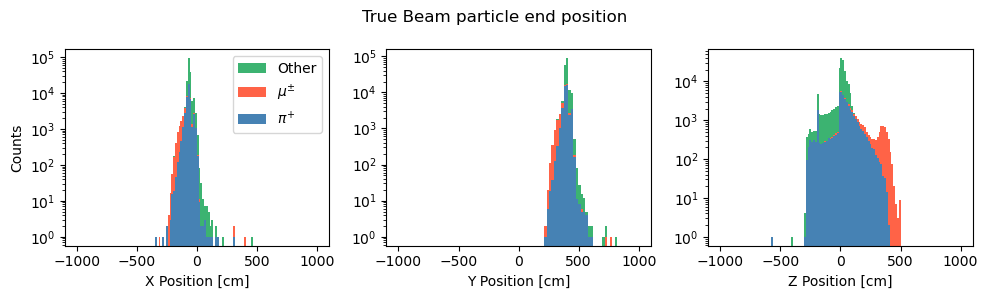

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)
bins_z = np.linspace(-1000, 500, 100)


ax[0].hist(
    [pion_endpos.x, muon_endpos.x, rest_endpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [pion_endpos.y, muon_endpos.y, rest_endpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[2].hist(
    [pion_endpos.z, muon_endpos.z, rest_endpos.z],
    bins=bins_z,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[2].set_xlabel('Z Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
fig.suptitle('True Beam particle end position')
ax[0].legend()
plt.tight_layout()
plt.show()

In [32]:
reco_endpos = events.recoParticles.beam_endPos_SCE

reco_pion_endpos = reco_endpos[pion_mask]
reco_muon_endpos = reco_endpos[muon_mask]
reco_rest_endpos = reco_endpos[rest_mask]

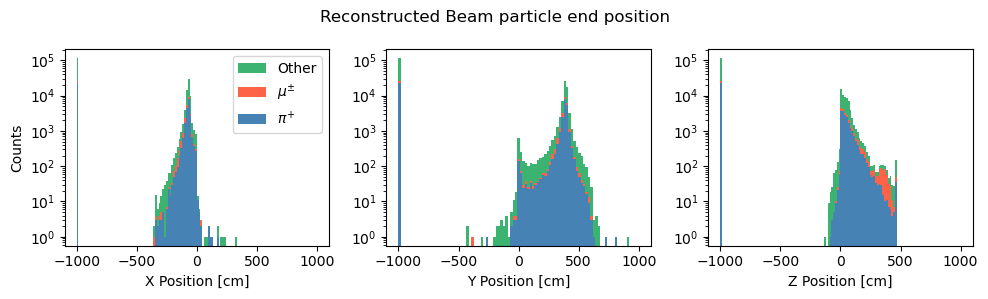

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)
bins_z = np.linspace(-1000, 500, 100)


ax[0].hist(
    [reco_pion_endpos.x, reco_muon_endpos.x, reco_rest_endpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [reco_pion_endpos.y, reco_muon_endpos.y, reco_rest_endpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[2].hist(
    [reco_pion_endpos.z, reco_muon_endpos.z, reco_rest_endpos.z],
    bins=bins_z,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[2].set_xlabel('Z Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
fig.suptitle('Reconstructed Beam particle end position')
ax[0].legend()
plt.tight_layout()
plt.show()

# Beam Instrumentation Selection

In [34]:
from pdhd_mc.scripts.beam_particle_selction import BeamTriggerSelection

true_beam_mask = BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

<BarContainer object of 8 artists>

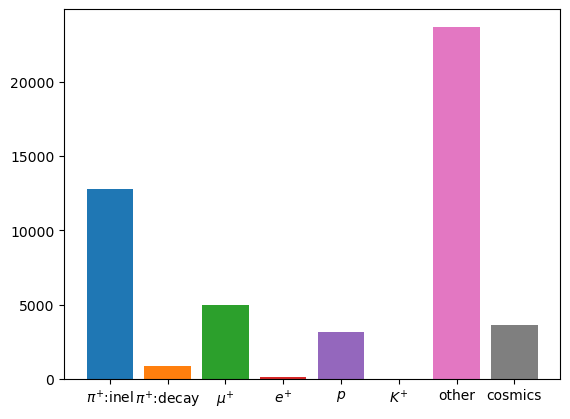

In [35]:
tags = Tags.GenerateTrueBeamParticleTags(bi_evts)
plt.bar(tags.name.values, ak.sum(tags.mask.values, axis=1), color= tags.colour.values)

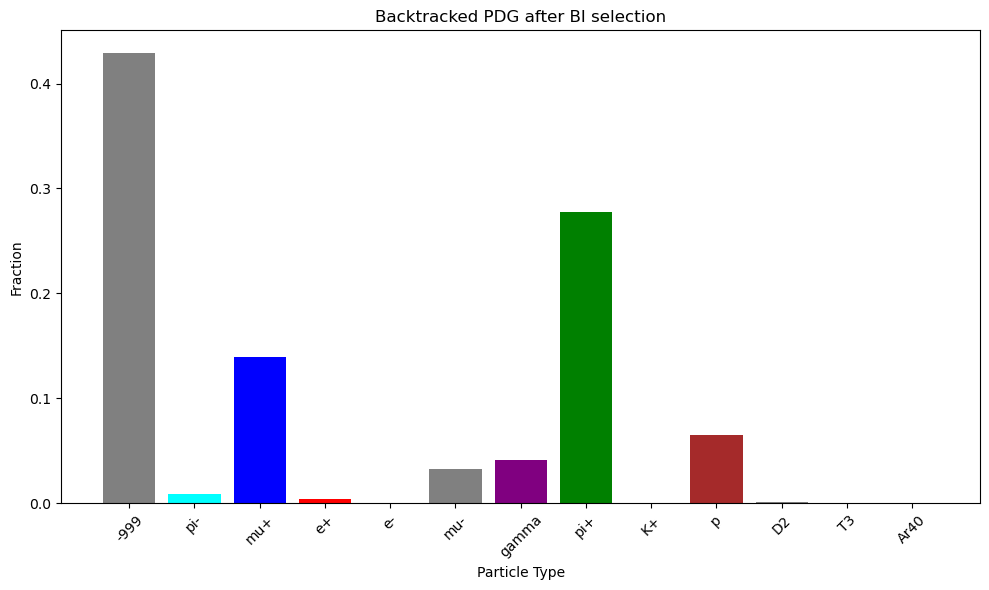

In [36]:
bt_pdg, counts = np.unique(bi_evts.trueParticlesBT.beam_pdg, return_counts=True)

particle_colors = {
    'pi-': 'cyan',
    'mu+': 'blue',
    'e+': 'red',
    'e-': 'orange',
    'gamma': 'purple',
    'pi+': 'green',
    'K+': 'magenta',
    'p': 'brown',
    '-999': 'gray'
}

particles = [
    Particle.from_pdgid(pdg).name if pdg != -999 else '-999'
    for pdg in bt_pdg
]

counts = counts / ak.sum(counts)
colors = [particle_colors.get(particle, 'gray') for particle in particles]

plt.figure(figsize=(10, 6))
plt.bar(particles, counts, color=colors)
plt.xlabel('Particle Type')
plt.ylabel('Fraction')
plt.title('Backtracked PDG after BI selection')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
purity = ak.sum(signal_mask(bi_evts)) / len(signal_mask(bi_evts))
print(f"Purity of the sample: {purity:.2%}")

efficiency = ak.sum(signal_mask(bi_evts)) / ak.sum(signal_mask(events))
print(f"Efficiency of the selection: {efficiency:.2%}")

Purity of the sample: 26.59%
Efficiency of the selection: 100.00%


In [159]:
beam_traj_pos = tpc_entrance_mask(bi_evts)

pion_mask, muon_mask, rest_mask = true_particle_masks(bi_evts)

In [39]:
beam_traj_KE = bi_evts.trueParticles.beam_traj_KE
beam_KE = ak.firsts(beam_traj_KE[beam_traj_pos])
beam_pion_KE = ak.firsts(beam_traj_KE[beam_traj_pos & pion_mask])
beam_muon_KE = ak.firsts(beam_traj_KE[beam_traj_pos & muon_mask])

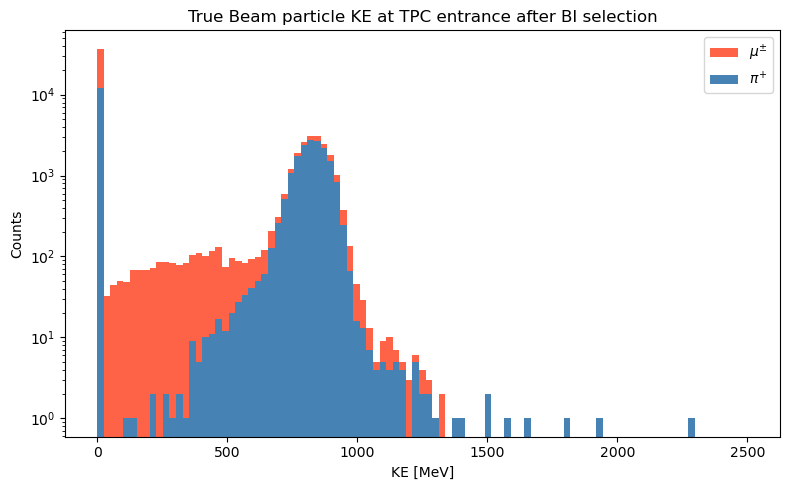

In [40]:
# Convert awkward arrays to numpy, dropping Nones from ak.firsts
pion_KE  = ak.fill_none(beam_pion_KE, 0)
muon_KE  = ak.fill_none(beam_muon_KE, 0)
#rest_KE  = ak.fill_none(beam_rest_KE, 0)

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [pion_KE, muon_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$'],
    color=['steelblue', 'tomato'],
    histtype='stepfilled',
)
#ax.hist(beam_KE, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('True Beam particle KE at TPC entrance after BI selection')
ax.legend()
plt.tight_layout()
plt.show()

In [160]:
pion_mask, muon_mask, rest_mask = particle_masks(bi_evts)

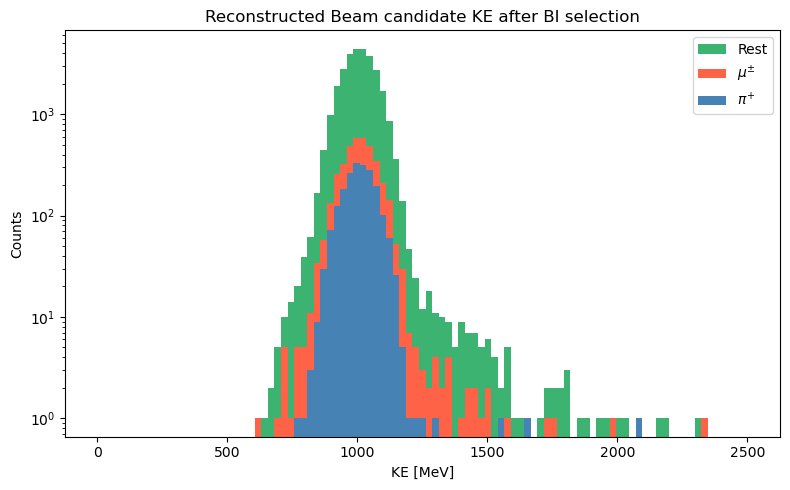

In [161]:
reco_energy = bi_evts.recoParticles.beam_inst_P

reco_pion_KE = reco_energy[pion_mask]
reco_muon_KE = reco_energy[muon_mask]
reco_rest_KE = reco_energy[rest_mask]

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [reco_pion_KE, reco_muon_KE, reco_rest_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(reco_energy, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('Reconstructed Beam candidate KE after BI selection')
ax.legend()
plt.tight_layout()
plt.show()

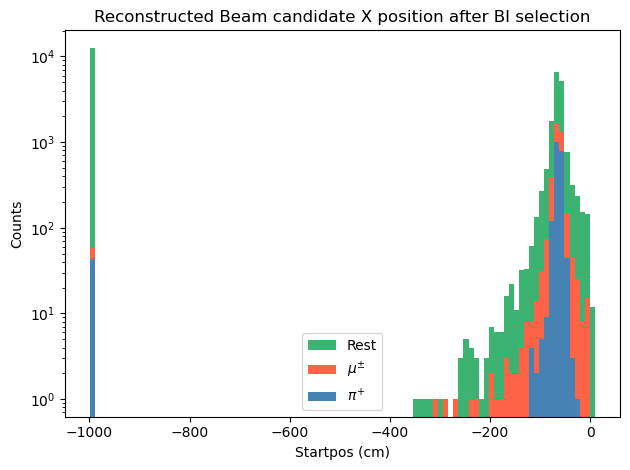

In [162]:
pion_startpos_x = bi_evts.recoParticles.beam_startPos.x[pion_mask]
muon_startpos_x = bi_evts.recoParticles.beam_startPos.x[muon_mask]
rest_startpos_x = bi_evts.recoParticles.beam_startPos.x[rest_mask]

plt.hist(
    [pion_startpos_x, muon_startpos_x, rest_startpos_x],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Startpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate X position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

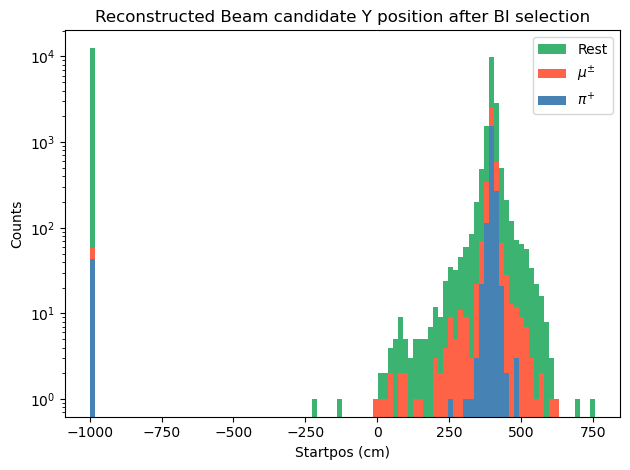

In [163]:
pion_startpos_y = bi_evts.recoParticles.beam_startPos.y[pion_mask]
muon_startpos_y = bi_evts.recoParticles.beam_startPos.y[muon_mask]
rest_startpos_y = bi_evts.recoParticles.beam_startPos.y[rest_mask]

plt.hist(
    [pion_startpos_y, muon_startpos_y, rest_startpos_y],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Startpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate Y position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

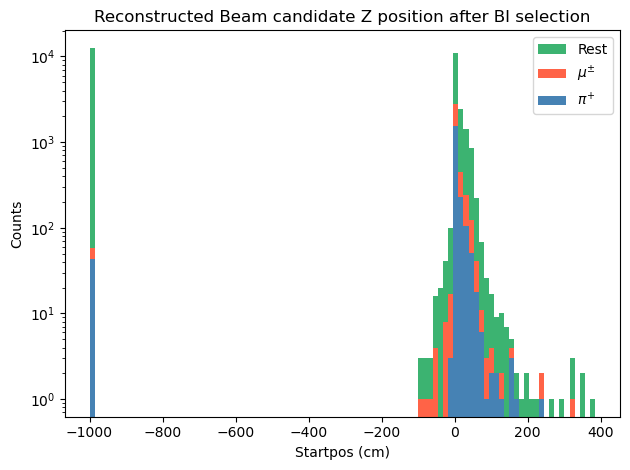

In [164]:
pion_startpos_z = bi_evts.recoParticles.beam_startPos.z[pion_mask]
muon_startpos_z = bi_evts.recoParticles.beam_startPos.z[muon_mask]
rest_startpos_z = bi_evts.recoParticles.beam_startPos.z[rest_mask]

plt.hist(
    [pion_startpos_z, muon_startpos_z, rest_startpos_z],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Startpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate Z position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

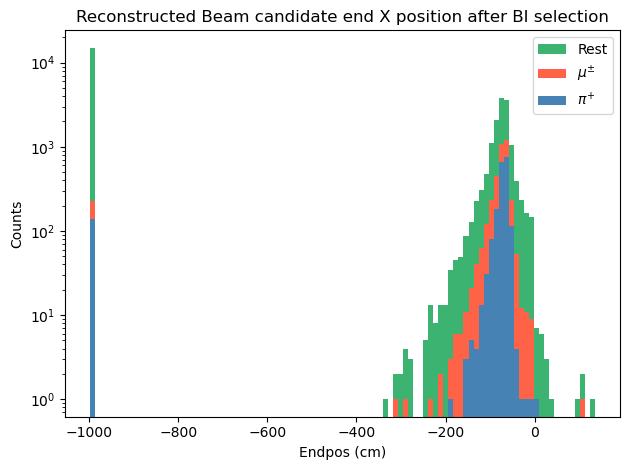

In [165]:
pion_endpos_x = bi_evts.recoParticles.beam_endPos_SCE.x[pion_mask]
muon_endpos_x = bi_evts.recoParticles.beam_endPos_SCE.x[muon_mask]
rest_endpos_x = bi_evts.recoParticles.beam_endPos_SCE.x[rest_mask]

plt.hist(
    [pion_endpos_x, muon_endpos_x, rest_endpos_x],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Endpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate end X position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

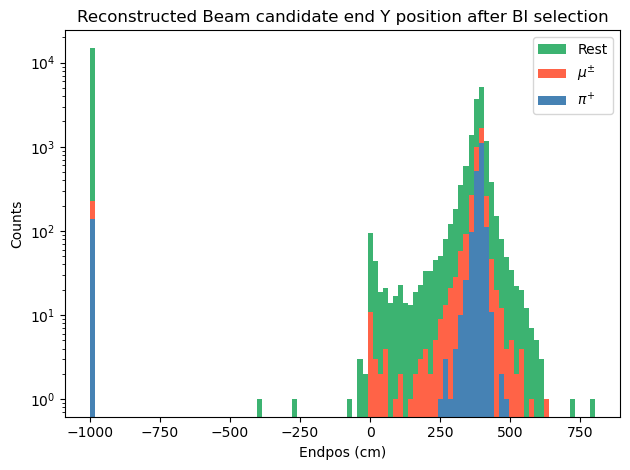

In [166]:
pion_endpos_y = bi_evts.recoParticles.beam_endPos_SCE.y[pion_mask]
muon_endpos_y = bi_evts.recoParticles.beam_endPos_SCE.y[muon_mask]
rest_endpos_y = bi_evts.recoParticles.beam_endPos_SCE.y[rest_mask]

plt.hist(
    [pion_endpos_y, muon_endpos_y, rest_endpos_y],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Endpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate end Y position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

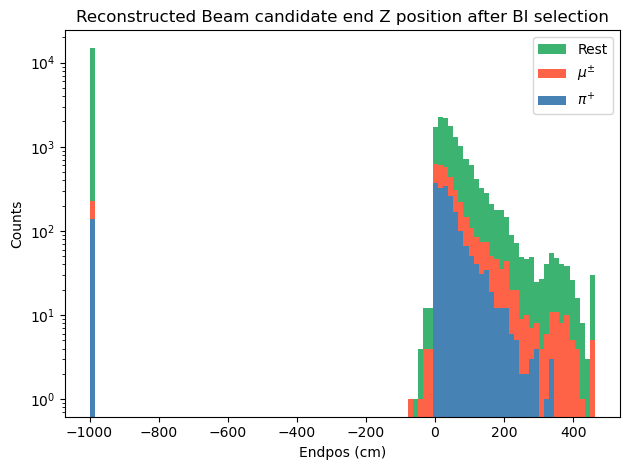

In [167]:
pion_endpos_z = bi_evts.recoParticles.beam_endPos_SCE.z[pion_mask]
muon_endpos_z = bi_evts.recoParticles.beam_endPos_SCE.z[muon_mask]
rest_endpos_z = bi_evts.recoParticles.beam_endPos_SCE.z[rest_mask]

plt.hist(
    [pion_endpos_z, muon_endpos_z, rest_endpos_z],
    bins=100,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Endpos (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Reconstructed Beam candidate end Z position after BI selection')
plt.legend()
plt.tight_layout()
plt.show()

# Reco Valid Beam Selection

In [168]:
n_beam_particles = events.recoParticles.beam_particles

In [50]:
n_beamparticle, counts = np.unique(n_beam_particles, return_counts=True)

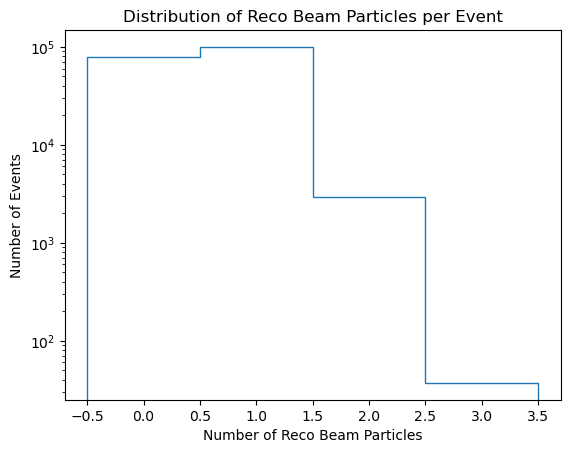

In [51]:
bins = np.arange(-0.5, np.max(n_beamparticle)+1.5, 1)
plt.hist(n_beam_particles, bins=bins, histtype='step')
plt.yscale('log')
plt.xlabel("Number of Reco Beam Particles")
plt.ylabel("Number of Events")
plt.title("Distribution of Reco Beam Particles per Event")
plt.show()

In [65]:
mask = true_beam_mask[0] & (events.recoParticles.beam_particles >= 1)

bv_evts = events.Filter([mask], [mask], returnCopy=True)

In [19]:
msk1 = events.trueParticlesBT.beam_endProcess == events.trueParticles.true_beam_endProcess 
msk2 = events.trueParticlesBT.beam_pdg == 211

ak.sum(msk1), ak.sum(msk2), ak.sum(msk1 & msk2)

(81693, 13698, 13108)

In [25]:
mask = true_beam_mask[0] & msk1 
filtered_evts = events.Filter([mask], [mask], returnCopy=True)

In [26]:
filtered_evts.event_index

<Array [0, 7, 9, ... 181314, 181354, 181363] type='10661 * int64'>

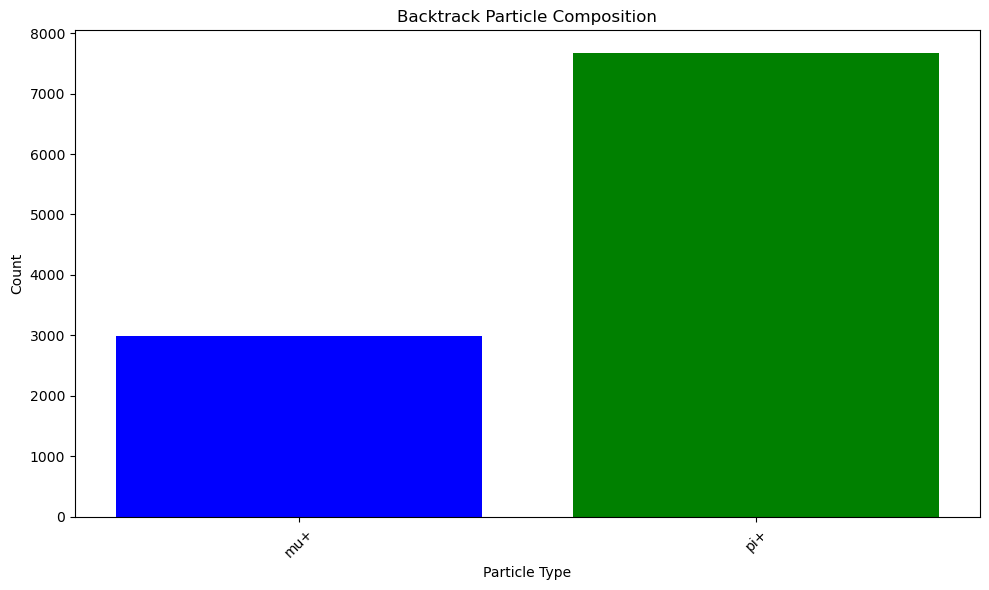

In [27]:
bt_pdg, counts = np.unique(filtered_evts.trueParticlesBT.beam_pdg, return_counts=True)
particles = [Particle.from_pdgid(pdg).name for pdg in bt_pdg]
particle_colors = {
    'pi-': 'cyan',
    'mu+': 'blue',
    'e+': 'red',
    'e-': 'orange',
    'gamma': 'purple',
    'pi+': 'green',
    'K+': 'magenta',
    'p': 'brown'
}
#counts = counts / ak.sum(counts)
colors = [particle_colors.get(particle, 'gray') for particle in particles]
plt.figure(figsize=(10, 6))
plt.bar(particles, counts, color=colors)
plt.xlabel('Particle Type')
plt.ylabel('Count')
plt.title('Backtrack Particle Composition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<BarContainer object of 8 artists>

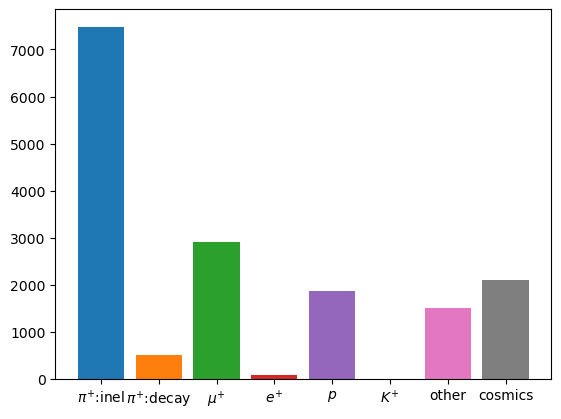

In [37]:
tags = Tags.GenerateTrueBeamParticleTags(bv_evts)
plt.bar(tags.name.values, ak.sum(tags.mask.values, axis=1), color= tags.colour.values)

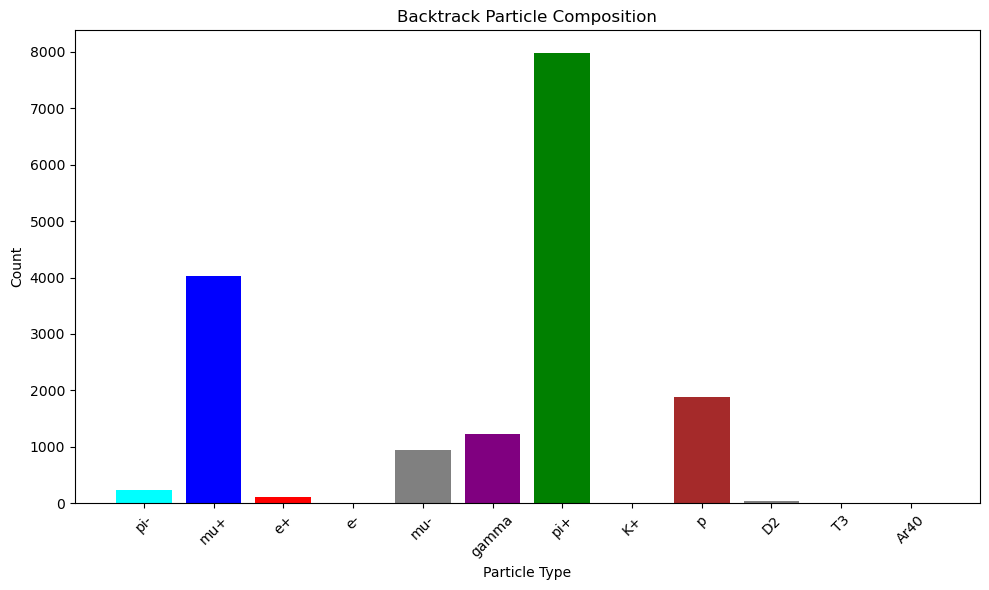

In [39]:
bt_pdg, counts = np.unique(bv_evts.trueParticlesBT.beam_pdg, return_counts=True)
particles = [Particle.from_pdgid(pdg).name for pdg in bt_pdg]
particle_colors = {
    'pi-': 'cyan',
    'mu+': 'blue',
    'e+': 'red',
    'e-': 'orange',
    'gamma': 'purple',
    'pi+': 'green',
    'K+': 'magenta',
    'p': 'brown'
}
#counts = counts / ak.sum(counts)
colors = [particle_colors.get(particle, 'gray') for particle in particles]
plt.figure(figsize=(10, 6))
plt.bar(particles, counts, color=colors)
plt.xlabel('Particle Type')
plt.ylabel('Count')
plt.title('Backtrack Particle Composition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

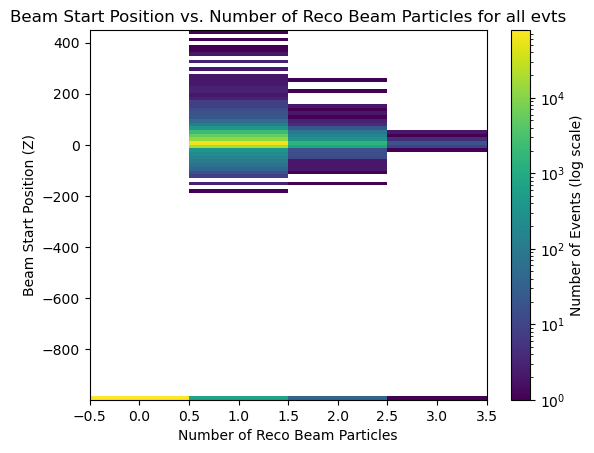

In [53]:
n_beam_particles = np.array(events.recoParticles.beam_particles)
start_pos = np.array(events.recoParticles.beam_startPos.z)

h, x, y, _ =plt.hist2d(
    n_beam_particles,
    start_pos,
    bins=(np.arange(-0.5, np.max(n_beam_particles)+1.5, 1), 100),
    norm=mcolors.LogNorm()
)

plt.xlabel("Number of Reco Beam Particles")
plt.ylabel("Beam Start Position (Z)")
plt.title("Beam Start Position vs. Number of Reco Beam Particles for all evts")

plt.colorbar(label="Number of Events (log scale)")
plt.show()

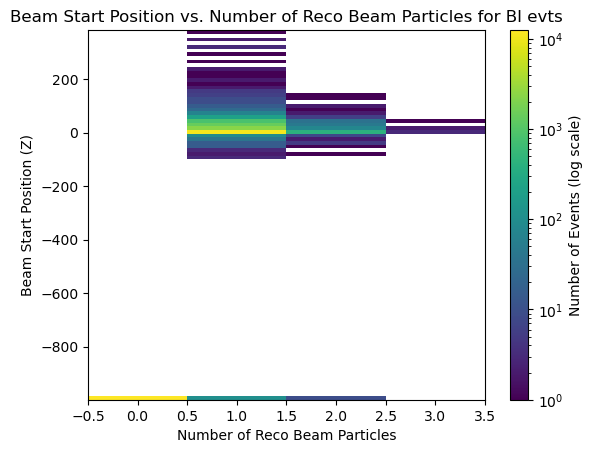

In [54]:
n_beam_particles = np.array(bi_evts.recoParticles.beam_particles)
start_pos = np.array(bi_evts.recoParticles.beam_startPos.z)

h, x, y, _ = plt.hist2d(
    n_beam_particles,
    start_pos,
    bins=(np.arange(-0.5, np.max(n_beam_particles)+1.5, 1), 100),
    norm=mcolors.LogNorm()
)

plt.xlabel("Number of Reco Beam Particles")
plt.ylabel("Beam Start Position (Z)")
plt.title("Beam Start Position vs. Number of Reco Beam Particles for BI evts")

plt.colorbar(label="Number of Events (log scale)")
plt.show()

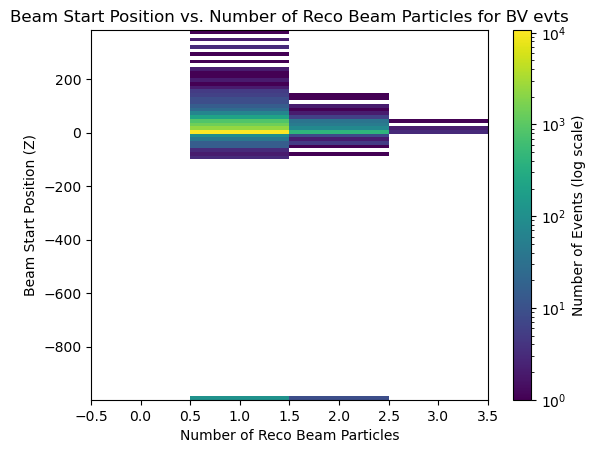

In [55]:
n_beam_particles = np.array(bv_evts.recoParticles.beam_particles)
start_pos = np.array(bv_evts.recoParticles.beam_startPos.z)

h, x, y, _ = plt.hist2d(
    n_beam_particles,
    start_pos,
    bins=(np.arange(-0.5, np.max(n_beam_particles)+1.5, 1), 100),
    norm=mcolors.LogNorm()
)

plt.xlabel("Number of Reco Beam Particles")
plt.ylabel("Beam Start Position (Z)")
plt.title("Beam Start Position vs. Number of Reco Beam Particles for BV evts")

plt.colorbar(label="Number of Events (log scale)")
plt.show()

In [169]:
signal_evts = ak.sum(events.trueParticlesBT.beam_pdg == 211)
print(f"Total events: {len(events.event_index)}")
print(f"Signal events (pi+): {signal_evts}")

Total events: 181372
Signal events (pi+): 13698


In [170]:
pdg = ak.firsts(events.trueParticlesBT.pdg) == 211
beam_pdg = events.trueParticlesBT.beam_pdg == 211
number = ak.firsts(events.trueParticlesBT.number) == 1

In [171]:
def signal_filter(evts):
    return evts.trueParticlesBT.beam_pdg == 211

In [172]:
def signal_filter(evts):
    return evts.trueParticlesBT.beam_pdg == 211

def purity_efficiency(evts, filter_func):
    #signal_evts = ak.sum(filter_func(evts))
    signal_mask = filter_func(evts)
    purity = ak.sum(signal_mask) / len(signal_mask) if len(signal_mask) > 0 else 0
    efficiency = ak.sum(signal_mask) / signal_evts if signal_evts > 0 else 0
    return purity, efficiency

In [173]:
purity, efficiency = purity_efficiency(events, signal_filter)
print(f"Purity: {purity:.2%}")
print(f"Efficiency: {efficiency:.2%}")

purity, efficiency = purity_efficiency(bi_evts, signal_filter)
print(f"Purity after BI selection: {purity:.2%}")
print(f"Efficiency after BI selection: {efficiency:.2%}")

purity, efficiency = purity_efficiency(bv_evts, signal_filter)
print(f"Purity after BV selection: {purity:.2%}")
print(f"Efficiency after BV selection: {efficiency:.2%}")

Purity: 7.55%
Efficiency: 100.00%
Purity after BI selection: 27.57%
Efficiency after BI selection: 58.28%
Purity after BV selection: 48.47%
Efficiency after BV selection: 58.28%


In [63]:
beam_traj_pos = tpc_entrance_mask(bv_evts)
pion_mask, muon_mask, rest_mask = true_particle_masks(bv_evts)

beam_traj_KE = bv_evts.trueParticles.beam_traj_KE
beam_KE = ak.firsts(beam_traj_KE[beam_traj_pos])
beam_pion_KE = ak.firsts(beam_traj_KE[beam_traj_pos & pion_mask])
beam_muon_KE = ak.firsts(beam_traj_KE[beam_traj_pos & muon_mask])

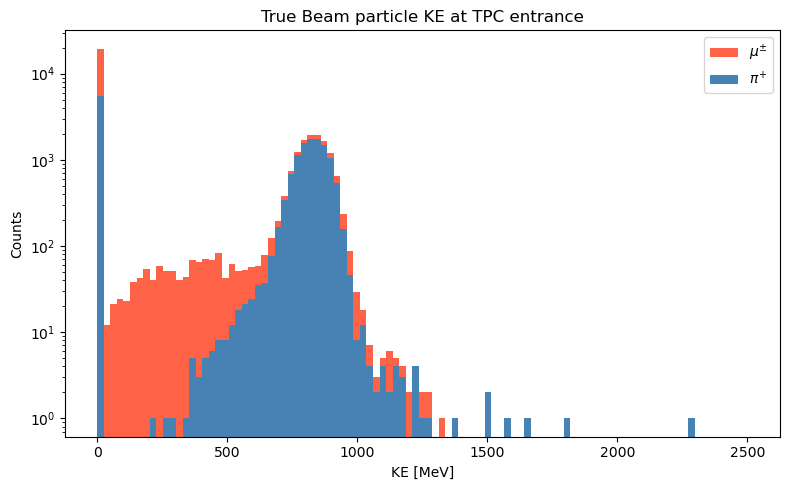

In [64]:
# Convert awkward arrays to numpy, dropping Nones from ak.firsts
pion_KE  = ak.fill_none(beam_pion_KE, 0)
muon_KE  = ak.fill_none(beam_muon_KE, 0)
beam_KE = ak.fill_none(beam_KE, 0)

bins = np.linspace(0, 2500, 100)  # adjust range to suit your data

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [pion_KE, muon_KE],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$'],
    color=['steelblue', 'tomato'],
    histtype='stepfilled',
)
#ax.hist(beam_KE, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
plt.yscale('log')
ax.set_title('True Beam particle KE at TPC entrance')
ax.legend()
plt.tight_layout()
plt.show()

In [65]:
beam_startpos = bv_evts.trueParticles.beam_traj_pos[beam_traj_pos]
beam_startpos = ak.firsts(beam_startpos)

beam_startpos = ak.zip({
    "x": ak.fill_none(beam_startpos.x, -999),
    "y": ak.fill_none(beam_startpos.y, -999),
    "z": ak.fill_none(beam_startpos.z, -999),
})

pion_startpos = beam_startpos[pion_mask]
muon_startpos = beam_startpos[muon_mask]
rest_startpos = beam_startpos[rest_mask]

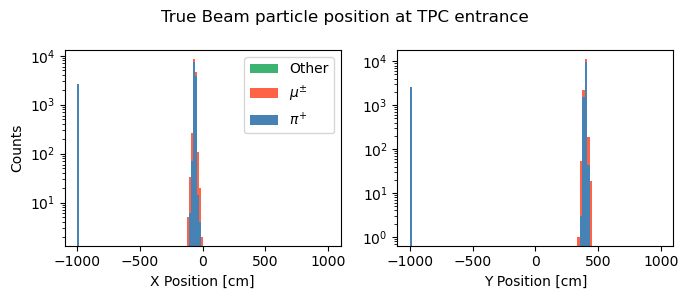

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)


ax[0].hist(
    [pion_startpos.x, muon_startpos.x, rest_startpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [pion_startpos.y, muon_startpos.y, rest_startpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)

ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('True Beam particle position at TPC entrance')
ax[0].legend()
plt.tight_layout()
plt.show()

In [67]:
reco_startpos = bv_evts.recoParticles.beam_startPos_SCE

reco_pion_startpos = reco_startpos[pion_mask]
reco_muon_startpos = reco_startpos[muon_mask]
reco_rest_startpos = reco_startpos[rest_mask]

reco_endpos = bv_evts.recoParticles.beam_endPos_SCE
reco_pion_endpos = reco_endpos[pion_mask]
reco_muon_endpos = reco_endpos[muon_mask]
reco_rest_endpos = reco_endpos[rest_mask]

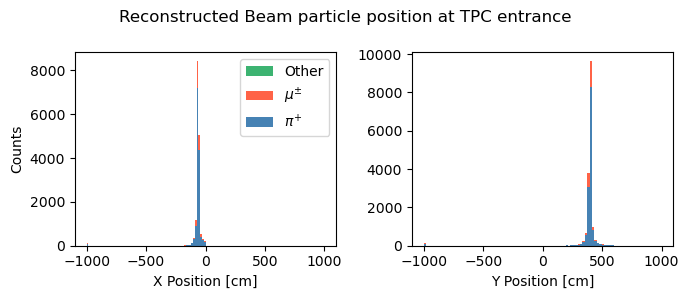

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)

bins_x = np.linspace(-1000, 500, 100)
bins_y = np.linspace(-1000, 1000, 100)


ax[0].hist(
    [reco_pion_startpos.x, reco_muon_startpos.x, reco_rest_startpos.x],
    bins=bins_x,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
ax[1].hist(
    [reco_pion_startpos.y, reco_muon_startpos.y, reco_rest_startpos.y],
    bins=bins_y,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', 'Other'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)

ax[0].set_xlabel('X Position [cm]')
ax[1].set_xlabel('Y Position [cm]')
ax[0].set_ylabel('Counts')
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
fig.suptitle('Reconstructed Beam particle position at TPC entrance')
ax[0].legend()
plt.tight_layout()
plt.show()

In [68]:
reco_startpos = bv_evts.recoParticles.beam_startPos_SCE

In [69]:
from python.analysis import Fitting, cross_section

mu, mu_err, sigma, sigma_err = {}, {}, {}, {}

for i in ["x", "y"]:
    data = reco_startpos[i]
    range = sorted([np.nanpercentile(data, 10), np.nanpercentile(data, 90)])

    # fit only to data within the 10th and 90th percentile of data to exclude large tails in the distriubtion.
    y, bins_edges = np.histogram(np.array(data[~np.isnan(data)]), bins = 10, range = range) 

    yerr = np.sqrt(y) # Poisson error

    popt, perr = Fitting.Fit(cross_section.bin_centers(bins_edges), y, yerr, Fitting.gaussian)

    mu[i] = popt[1]
    sigma[i] = abs(popt[2])
    mu_err[i] = abs(perr[1])
    sigma_err[i] = abs(perr[2])

In [70]:
def plot_range(mu, sigma):
    return [mu - 5*sigma, mu + 5*sigma]

plot_ranges = {i: plot_range(mu[i], sigma[i]) for i in ["x", "y"]}

x_label = f"Beam start {i} position (cm)"
color = "steelblue"
label = "MC"

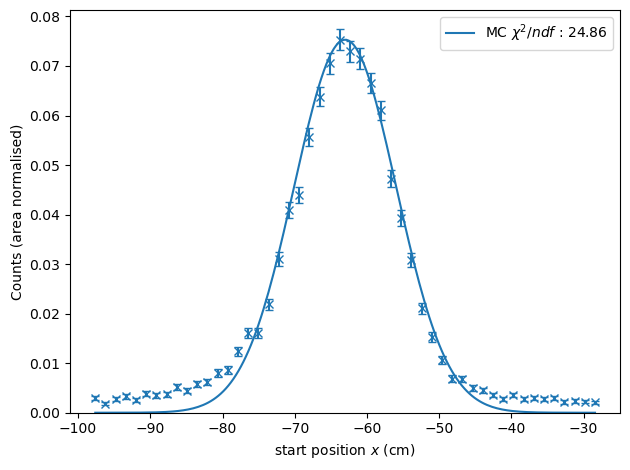

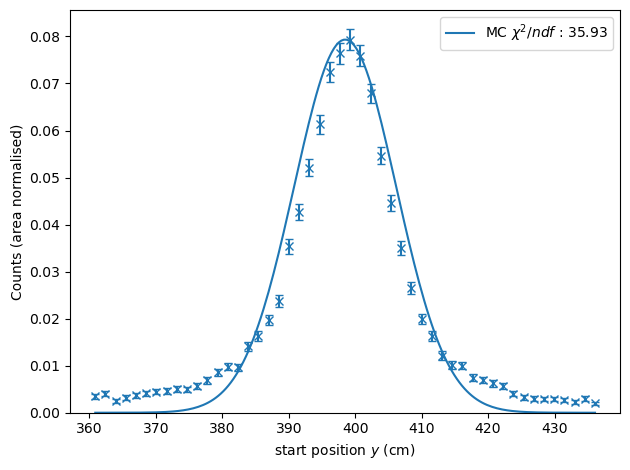

In [71]:
import apps.cex_beam_quality_fits as beam_qual

def plot_range(mu, sigma):
    return [mu - 5*sigma, mu + 5*sigma]

for i in ["x", "y"]:
    beam_qual.plot(reco_startpos[i], f"start position ${i}$ (cm)", mu[i], sigma[i], "C0", "MC", range = [min(plot_ranges[i]), max(plot_ranges[i])])
    plt.show()

In [42]:
pion_mask, muon_mask, rest_mask = particle_masks(bv_evts)

In [44]:
ak.sum(pion_mask), ak.sum(muon_mask), ak.sum(rest_mask)

(2012, 1788, 12670)

In [72]:
beam_dx = (reco_startpos.x - mu["x"])/ sigma["x"] 
beam_dy = (reco_startpos.y - mu["y"])/ sigma["y"]
beam_dxy = (beam_dx**2 + beam_dy**2)**0.5

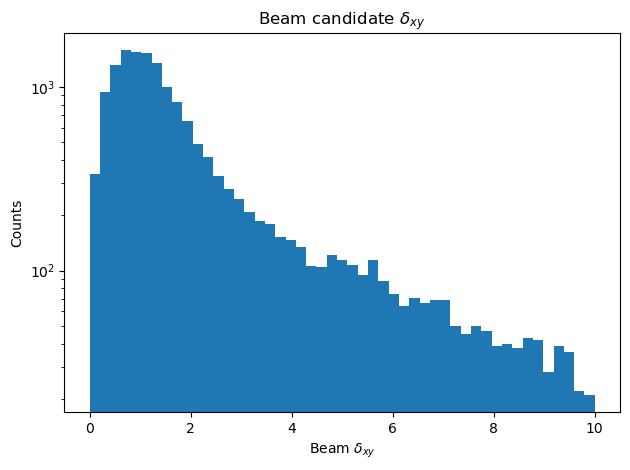

In [77]:
bins = np.linspace(0, 10, 50)
plt.hist(beam_dxy,
    bins=bins,
    stacked=True,
    histtype='stepfilled'
)
plt.xlabel('Beam $\delta_{{xy}}$')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Beam candidate $\delta_{{xy}}$')
#plt.legend()
plt.tight_layout()
plt.show()

In [73]:
tags = Tags.GenerateTrueBeamParticleTags(bv_evts)

particle_tags = tags.name.values
masks = {name: tags.get(name).mask for name in particle_tags}

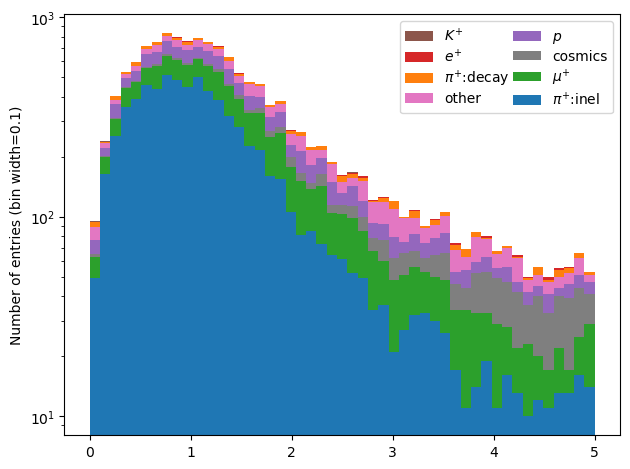

In [74]:
from python.analysis import Plots
bins = np.linspace(0, 5, 50)
Plots.PlotTagged(beam_dxy, tags, bins=bins, y_scale='log')


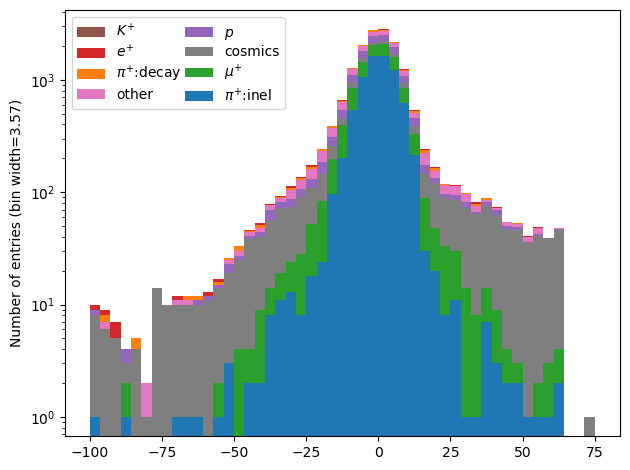

In [75]:
beam_dx = (reco_startpos.x - mu["x"]) 
bins = np.linspace(-100, 75, 50)
Plots.PlotTagged(beam_dx, tags, bins=bins, y_scale='log')

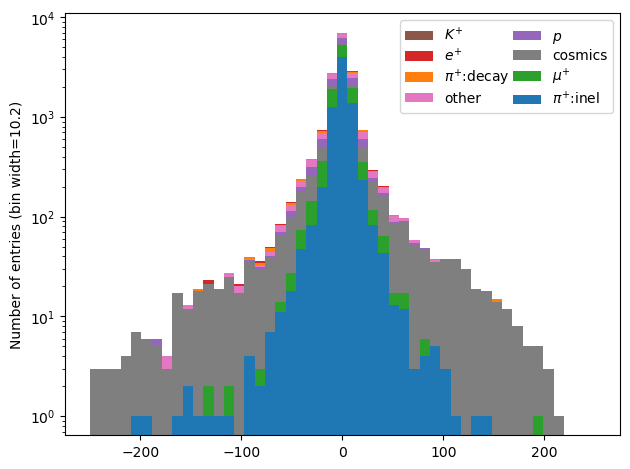

In [76]:
beam_dx = (reco_startpos.y - mu["y"]) 
bins = np.linspace(-250, 250, 50)
Plots.PlotTagged(beam_dx, tags, bins=bins, y_scale='log')

In [77]:
from python.analysis import vector

end_pos = bv_evts.recoParticles.beam_endPos_SCE
start_pos = bv_evts.recoParticles.beam_startPos_SCE
beam_dir = vector.normalize(vector.sub(end_pos, start_pos))

mu_dir = {i : ak.mean(ak.nan_to_num(beam_dir[i])) for i in ["x", "y", "z"]}
mu_dir_err = {i : ak.std(ak.nan_to_num(beam_dir[i]))/np.sqrt(ak.count(beam_dir[i])) for i in ["x", "y", "z"]}

beam_dir_mc = vector.normalize(vector.vector(mu_dir["x"], mu_dir["y"], mu_dir["z"]))
beam_costh = vector.dot(beam_dir, beam_dir_mc)

(0.9, 1.0)

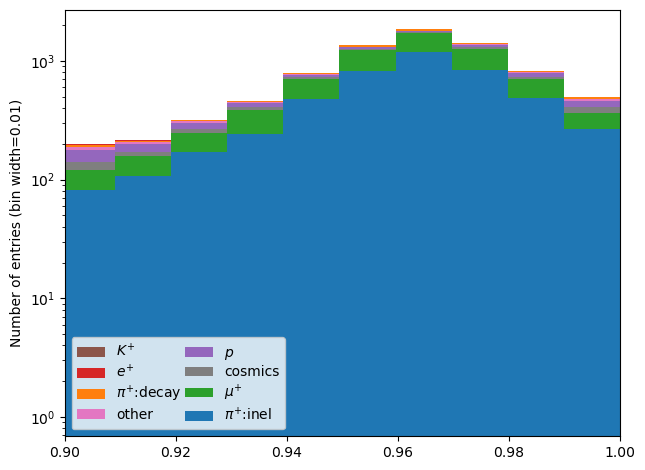

In [80]:
bins = np.linspace(0, 1, 100)

Plots.PlotTagged(beam_costh, tags, bins=bins, y_scale='log')
plt.xlim(0.9, 1)

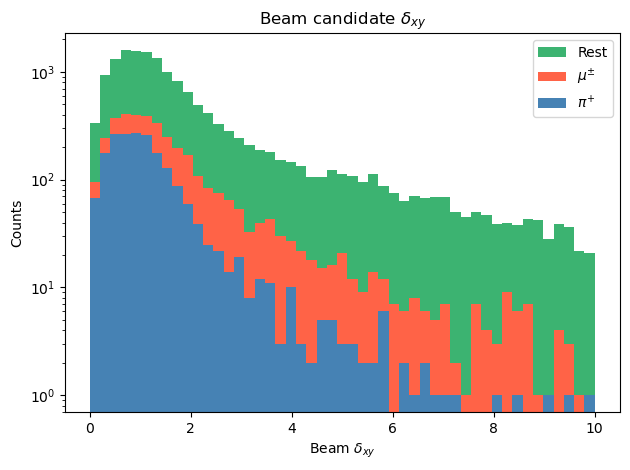

In [181]:
bins = np.linspace(0, 10, 50)
plt.hist(
    [beam_dxy[pion_mask], beam_dxy[muon_mask], beam_dxy[rest_mask]],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
plt.xlabel('Beam $\delta_{{xy}}$')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Beam candidate $\delta_{{xy}}$')
plt.legend()
plt.tight_layout()
plt.show()

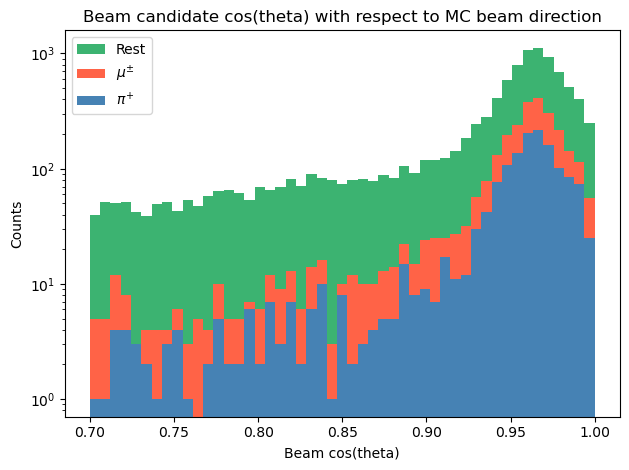

In [186]:
bins = np.linspace(0.7, 1, 50)
plt.hist([beam_costh[pion_mask],
          beam_costh[muon_mask],
          beam_costh[rest_mask]],
          bins=bins, stacked=True,
          label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'Rest'], color=['steelblue', 'tomato', 'mediumseagreen'],
          histtype='stepfilled')
plt.xlabel('Beam cos(theta)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Beam candidate cos(theta) with respect to MC beam direction')
plt.legend()
plt.tight_layout()
plt.show()

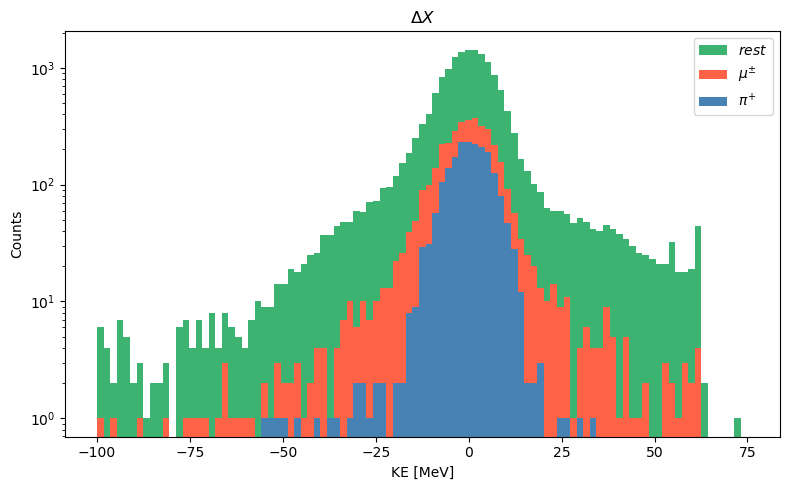

In [187]:
beam_dx = (reco_startpos.x - mu["x"]) 
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-100, 75, 100)  # adjust range to suit your data

ax.hist(
    [beam_dx[pion_mask], beam_dx[muon_mask], beam_dx[rest_mask]],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'$rest$'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(beam_KE, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
#plt.xlim(-30, 30)
plt.yscale('log')
ax.set_title('$\Delta X$')
ax.legend()
plt.tight_layout()
plt.show()

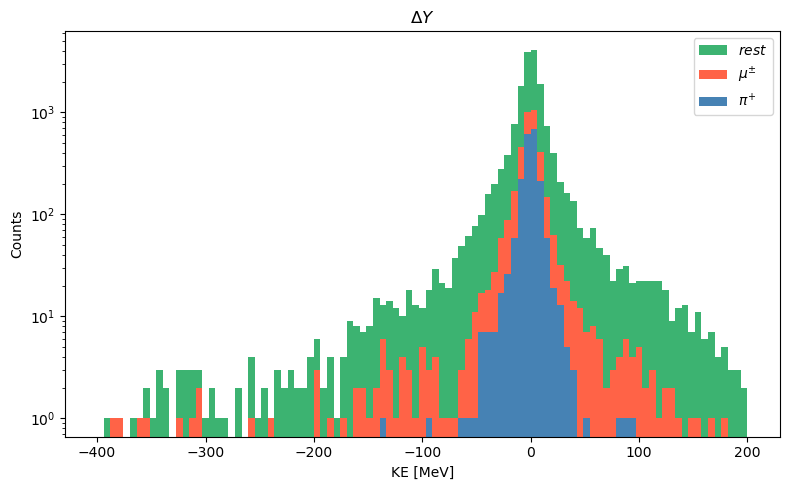

In [188]:
beam_dy = (reco_startpos.y - mu["y"]) 

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-400, 200, 100)  # adjust range to suit your data
ax.hist(
    [beam_dy[pion_mask], beam_dy[muon_mask], beam_dy[rest_mask]],
    bins=bins,
    stacked=True,
    label=[r'$\pi^{+}$', r'$\mu^{\pm}$', r'$rest$'],
    color=['steelblue', 'tomato', 'mediumseagreen'],
    histtype='stepfilled',
)
#ax.hist(beam_KE, bins=bins, histtype='step', color='black', label='Total', linewidth=1.5)

ax.set_xlabel('KE [MeV]')
ax.set_ylabel('Counts')
#plt.xlim(-30, 30)
plt.yscale('log')
ax.set_title('$\Delta Y$')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Beam Scraper related variables

# beam_inst_KE = EnergyTools.KE(events.recoParticles.beam_inst_P, Particle.from_pdgid(211).mass) # get kinetic energy from beam instrumentation
# true_ffKE = events.trueParticles.beam_KE_front_face

# beam_inst_x = events.recoParticles.beam_inst_pos.x
# beam_inst_y = events.recoParticles.beam_inst_pos.y

# delta_KE_upstream = beam_inst_KE - true_ffKE

## Energy

In [165]:
beam_traj_z = events.trueParticles.beam_traj_pos.z
beam_traj_z = beam_traj_z[beam_traj_z < 0]
beam_traj_pos = events.trueParticles.beam_traj_pos.z == beam_traj_z[:, -1]

In [ ]:
# beam_traj_z = trueParticles.beam_traj_pos.z
# beam_traj_z = beam_traj_z[beam_traj_z > 0]
# beam_traj_z = ak.fill_none(ak.pad_none(beam_traj_z, 1, axis=-1), 0, axis=-1)
# beam_traj_pos2 = trueParticles.beam_traj_pos.z == beam_traj_z[:, 0]

# beam_traj_KE = trueParticles.beam_traj_KE
# beam_traj_KE1 = beam_traj_KE[beam_traj_pos1]
# beam_traj_KE2 = beam_traj_KE[beam_traj_pos2]

In [167]:
beam_traj_KE = events.trueParticles.beam_traj_KE
beam_traj_KE = beam_traj_KE[beam_traj_pos]
beam_ke = ak.firsts(beam_traj_KE)
beam_ke = beam_ke[beam_ke < 2500]

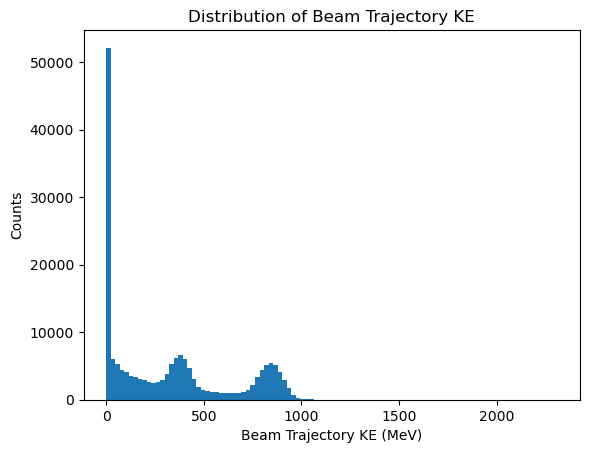

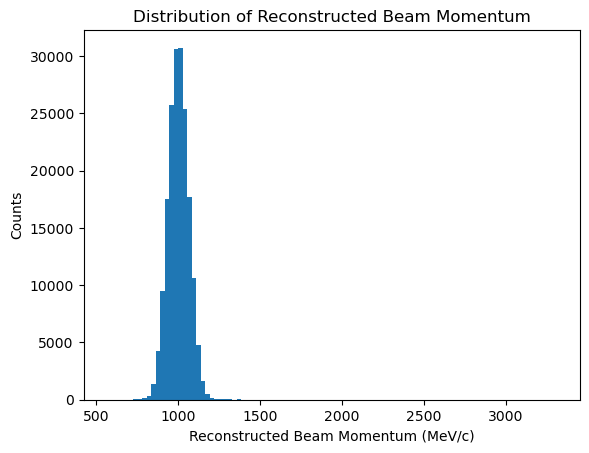

In [169]:
plt.hist(beam_ke, bins=100)
plt.xlabel("Beam Trajectory KE (MeV)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of Beam Trajectory KE") 
plt.show()

reco_energy = events.recoParticles.beam_inst_P
plt.hist(reco_energy, bins=100)
plt.xlabel("Reconstructed Beam Momentum (MeV/c)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of Reconstructed Beam Momentum")
plt.show()

In [170]:
pion_mask = events.trueParticles.pdg[:, 0] == 211
muon_mask = (events.trueParticles.pdg[:, 0] == -13) | (events.trueParticles.pdg[:, 0] == 13)
rest_mask = ~(pion_mask | muon_mask)

In [171]:
ak.sum(pion_mask), ak.sum(muon_mask), ak.sum(rest_mask)

(41886, 7413, 132073)

In [172]:
beam_traj_KE = events.trueParticles.beam_traj_KE
beam_pion_KE = beam_traj_KE[beam_traj_pos & pion_mask]
beam_pion_KE = ak.firsts(beam_pion_KE)
beam_muon_KE = beam_traj_KE[beam_traj_pos & muon_mask]
beam_muon_KE = ak.firsts(beam_muon_KE)
beam_rest_KE = beam_traj_KE[beam_traj_pos & rest_mask]
beam_rest_KE = ak.firsts(beam_rest_KE)

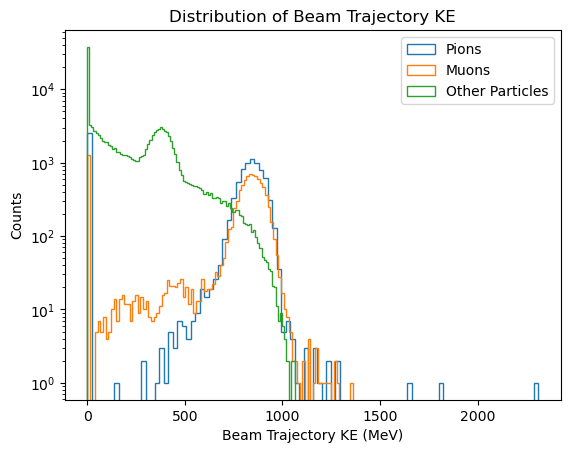

In [194]:
#beam_ke = trueParticles.beam_traj_KE[:, 0]
#beam_pion_ke = ak.flatten(beam_pion_KE)
beam_pion_ke = beam_pion_KE[beam_pion_KE < 2500]
#beam_muon_ke = ak.flatten(beam_muon_KE)
beam_muon_ke = beam_muon_KE[beam_muon_KE < 2500]
#beam_rest_ke = ak.flatten(beam_rest_KE)
beam_rest_ke = beam_rest_KE[beam_rest_KE < 2500]
plt.hist(beam_pion_ke, bins=100, histtype="step", label="Pions")
plt.hist(beam_muon_ke, bins=100, histtype="step", label="Muons")
plt.hist(beam_rest_ke, bins=100, histtype="step", label="Other Particles")
plt.xlabel("Beam Trajectory KE (MeV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Distribution of Beam Trajectory KE")
plt.legend()
plt.show()

# res_ke = reco_energy - beam_ke
# plt.hist(res_ke, bins=100)
# plt.xlabel("Reconstructed - True Beam KE (MeV)")
# plt.ylabel("Counts")
# plt.title("Distribution of Reconstruction Residuals")
# plt.show()

In [174]:
beam_traj_KE = pre_sel_events.trueParticles.beam_traj_KE
beam_traj_z = pre_sel_events.trueParticles.beam_traj_pos.z
beam_traj_z = beam_traj_z[beam_traj_z < 0]
beam_traj_pos = pre_sel_events.trueParticles.beam_traj_pos.z == beam_traj_z[:, -1]
beam_traj_KE = beam_traj_KE[beam_traj_pos]

beam_ke = ak.firsts(beam_traj_KE)
beam_ke = beam_ke[beam_ke < 2500]

reco_energy = pre_sel_events.recoParticles.beam_inst_P

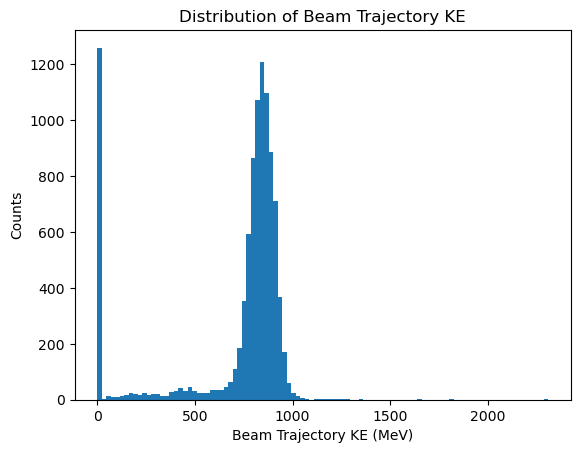

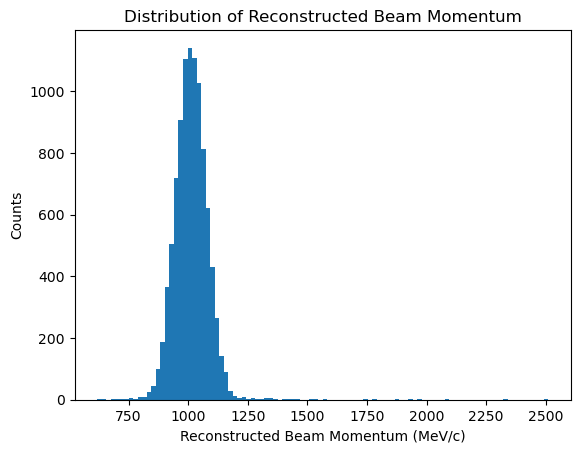

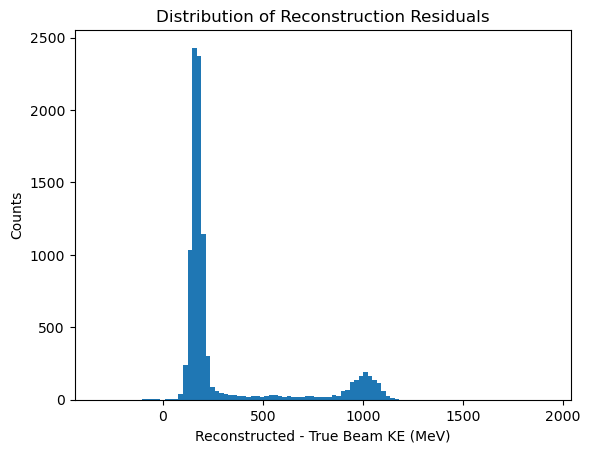

In [175]:
plt.hist(beam_ke, bins=100)
plt.xlabel("Beam Trajectory KE (MeV)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of Beam Trajectory KE") 
plt.show()


plt.hist(reco_energy, bins=100)
plt.xlabel("Reconstructed Beam Momentum (MeV/c)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of Reconstructed Beam Momentum")
plt.show()

plt.hist(reco_energy - beam_ke, bins=100)
plt.xlabel("Reconstructed - True Beam KE (MeV)")
plt.ylabel("Counts")
plt.title("Distribution of Reconstruction Residuals")
plt.show()

In [176]:
pion_mask = pre_sel_events.trueParticles.pdg[:, 0] == 211
muon_mask = (pre_sel_events.trueParticles.pdg[:, 0] == -13) | (pre_sel_events.trueParticles.pdg[:, 0] == 13)

In [177]:
beam_traj_KE = pre_sel_events.trueParticles.beam_traj_KE
beam_pion_KE = beam_traj_KE[beam_traj_pos & pion_mask]
beam_pion_KE = ak.firsts(beam_pion_KE)
beam_muon_KE = beam_traj_KE[beam_traj_pos & muon_mask]
beam_muon_KE = ak.firsts(beam_muon_KE)

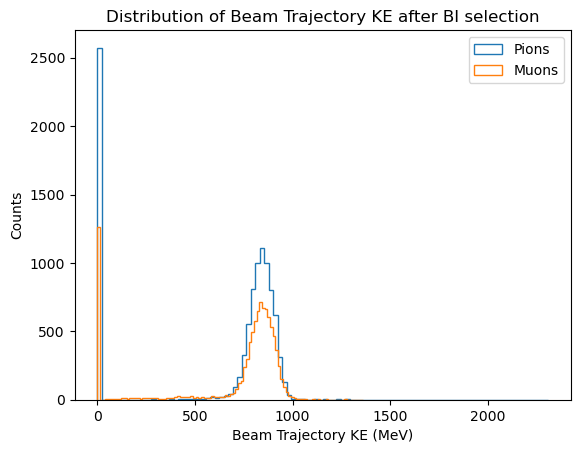

In [178]:
beam_pion_ke = beam_pion_KE[beam_pion_KE < 2500]
beam_muon_ke = beam_muon_KE[beam_muon_KE < 2500]

plt.hist(beam_pion_ke, bins=100, histtype="step", label="Pions")
plt.hist(beam_muon_ke, bins=100, histtype="step", label="Muons")
plt.xlabel("Beam Trajectory KE (MeV)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of Beam Trajectory KE after BI selection")
plt.legend()
plt.show()

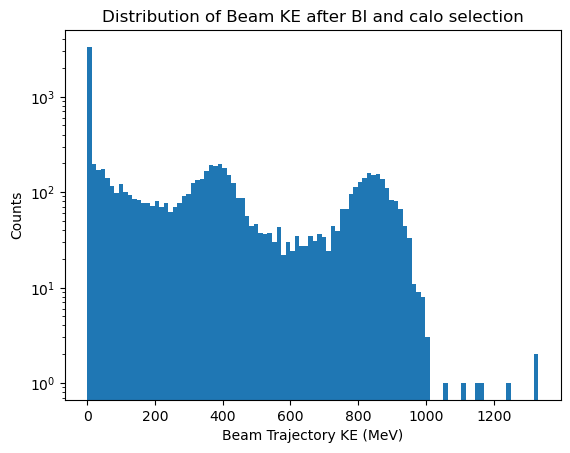

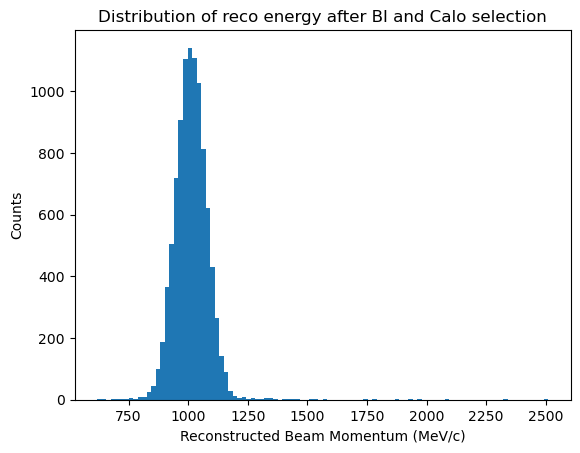

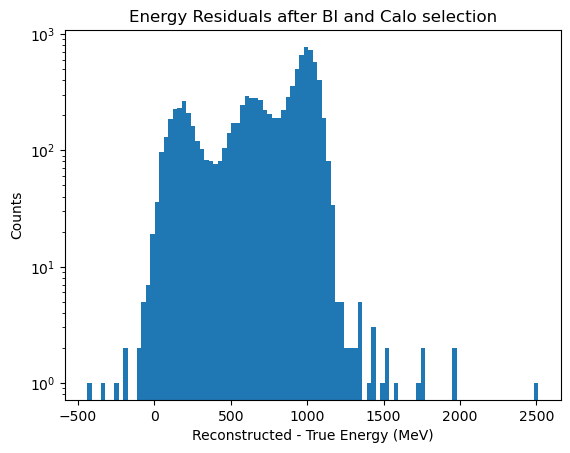

In [16]:
#beam_ke = trueParticles.beam_traj_KE[:, 0]
beam_ke = ak.flatten(beam_traj_KE)
beam_ke = beam_ke[true_beam_mask[0] & calo_mask]

plt.hist(beam_ke, bins=100)
plt.xlabel("Beam Trajectory KE (MeV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Distribution of Beam KE after BI and calo selection")
plt.show()

reco_energy = recoParticles.beam_inst_P[true_beam_mask[0] & calo_mask]
plt.hist(reco_energy, bins=100)
plt.xlabel("Reconstructed Beam Momentum (MeV/c)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Distribution of reco energy after BI and Calo selection")
plt.show()

res_energy = reco_energy - beam_ke
plt.hist(res_energy, bins=100)
plt.xlabel("Reconstructed - True Energy (MeV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Energy Residuals after BI and Calo selection")
plt.show()

/software/gj23442/miniconda3/envs/pdune_analysis/lib/python3.10/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in power
  result = getattr(ufunc, method)(


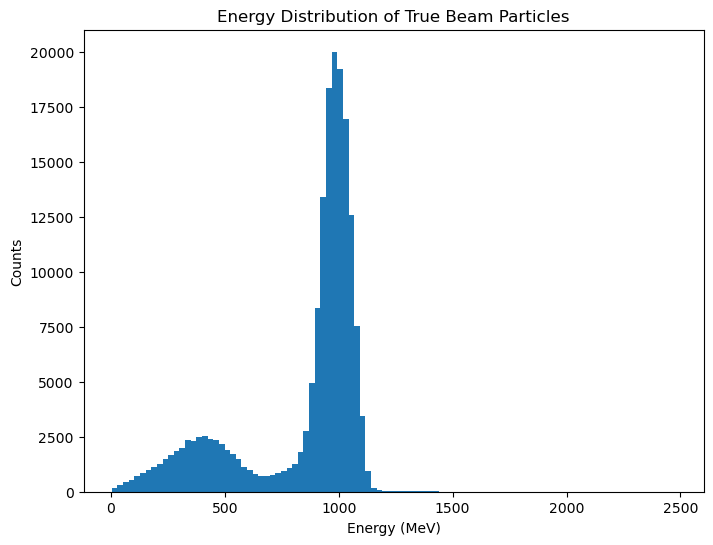

In [56]:
true_energy = trueParticles.energy[:, 0]
true_energy = true_energy[true_energy < 2500]

plt.figure(figsize=(8, 6))
counts, bins, _ = plt.hist(true_energy, bins=100)
plt.xlabel("Energy (MeV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of True Beam Particles")
#plt.yscale("log")
plt.show()
#plt.xlim(0, 2000)

In [61]:
true_beam_energy = trueParticles.energy[:, 0][true_beam_mask[0] & calo_mask]

/software/gj23442/miniconda3/envs/pdune_analysis/lib/python3.10/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in power
  result = getattr(ufunc, method)(


In [82]:
np.unique(trueParticles.pdg[:, 0][true_beam_mask[0] & calo_mask][true_beam_energy < 800], return_counts=True)   

(array([-13, 211], dtype=int32), array([328,   7]))

In [52]:
from scipy.optimize import curve_fit
mu = np.mean(true_beam_energy)
sigma = np.std(true_beam_energy)

counts, bins = np.histogram(true_beam_energy, bins=100)
popt, pcov = curve_fit(lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2/(2*sigma**2)),
                       bins[:-1], counts, p0=(max(counts), mu, sigma))

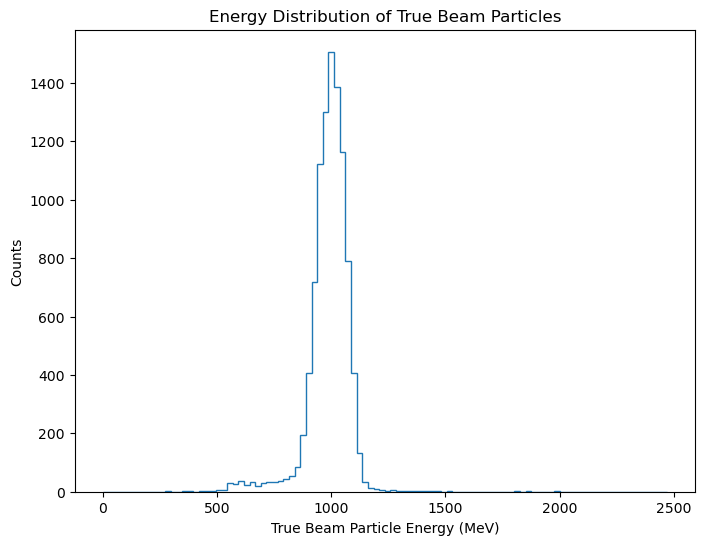

In [126]:
plt.figure(figsize=(8, 6))
plt.hist(true_beam_energy, bins=bins, histtype='step', label='Data')
#plt.plot(bins[:-1], popt[0] * np.exp(-(bins[:-1] - popt[1])**2/(2*popt[2]**2)), 'r-', label='Fitted Curve')
plt.xlabel("True Beam Particle Energy (MeV)")
plt.ylabel("Counts")
#plt.yscale("log")
plt.title("Energy Distribution of True Beam Particles")
plt.show()


In [ ]:
true_energy = trueParticles.energy[:, 0]
reco_energy = recoParticles.beam_inst_P
#res_energy = reco_energy - true_energy

/software/gj23442/miniconda3/envs/pdune_analysis/lib/python3.10/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in power
  result = getattr(ufunc, method)(


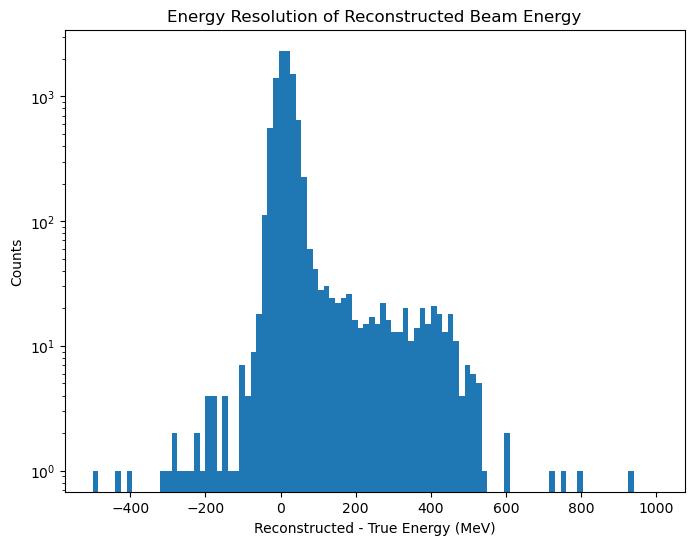

In [78]:
res_energy = reco_energy - true_energy
res_energy = res_energy[true_beam_mask[0] & calo_mask]
plt.figure(figsize=(8, 6))
plt.hist(res_energy, bins=100, range=(-500, 1000))
plt.xlabel("Reconstructed - True Energy (MeV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Energy Resolution of Reconstructed Beam Energy")
plt.show()

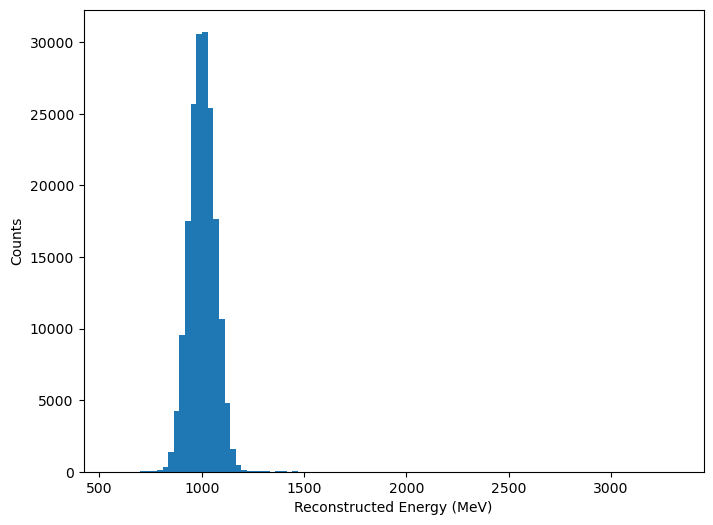

In [64]:
plt.figure(figsize=(8, 6))
plt.hist(reco_energy, bins=100)
plt.xlabel("Reconstructed Energy (MeV)")
plt.ylabel("Counts")
plt.show()

9719


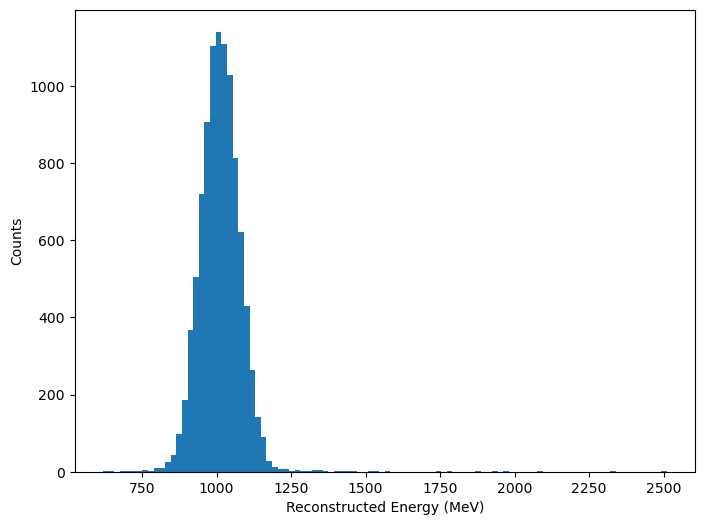

In [81]:
reco_beam_energy = recoParticles.beam_inst_P[true_beam_mask[0] & calo_mask]
print(len(reco_beam_energy))
plt.figure(figsize=(8, 6))
plt.hist(reco_beam_energy, bins=100)
#plt.plot(bins[:-1], popt[0] * np.exp(-(bins[:-1] - popt[1])**2/(2*popt[2]**2)), 'r-', label='Fitted Curve')
plt.xlabel("Reconstructed Energy (MeV)")
plt.ylabel("Counts")
plt.show()

In [69]:
res_energy = reco_beam_energy - true_beam_energy

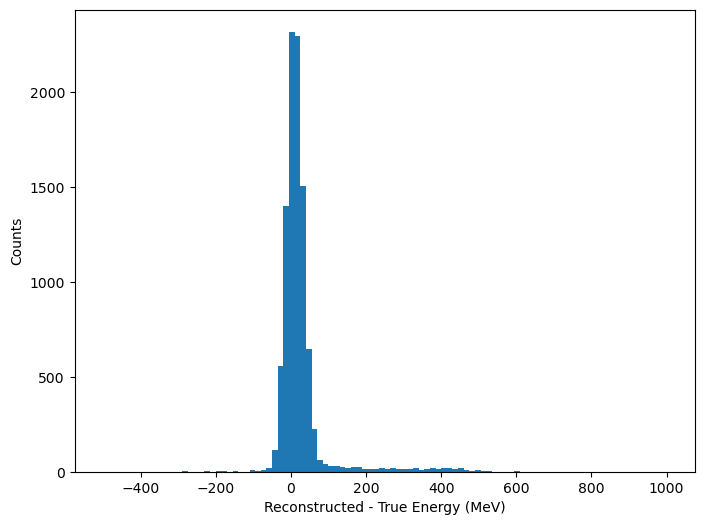

In [127]:
plt.figure(figsize=(8, 6))
plt.hist(res_energy, bins=100, range=(-500, 1000))
plt.xlabel("Reconstructed - True Energy (MeV)")
#plt.yscale("log")
plt.ylabel("Counts")
plt.show()

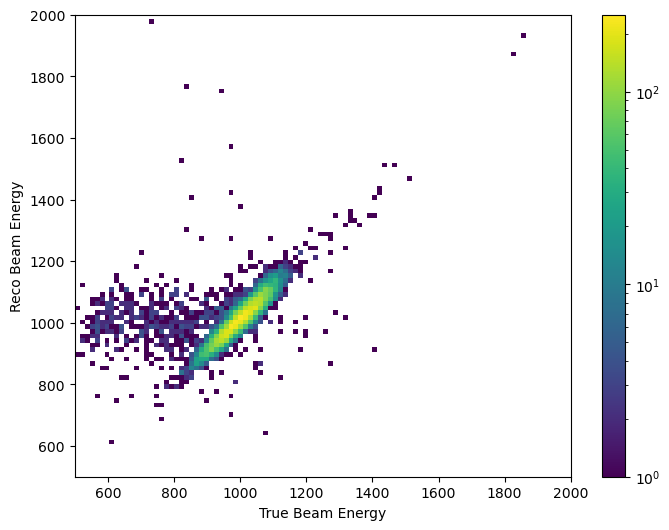

In [95]:
plt.figure(figsize=(8, 6))
plt.hist2d(np.array(true_beam_energy), np.array(reco_beam_energy), bins=(100, 100),
           range=[[500, 2000], [500, 2000]], norm=mcolors.LogNorm())
plt.colorbar()
plt.xlabel("True Beam Energy")
plt.ylabel("Reco Beam Energy")
plt.show()